# Assignment 1 



Put this notebook in the same folder as:

- `support.py`
- `dataset_a1.txt`


In [1]:
import random

import time

import numpy as np
import matplotlib.pyplot as plt

from deap import base, creator, tools, algorithms

import support


## GA parameters

These are the initial parameter values for Task 1. 

In [2]:
POPULATION_SIZE = 80
N_GENERATIONS = 45
CROSSOVER_PROBABILITY = 0.8
MUTATION_PROBABILITY = 0.2
TOURNAMENT_SIZE = 3
PER_GENE_MUTATION_PROBABILITY = 0.05

RANDOM_SEED = 42

## Individual representation

A candidate Petri net is represented as a linearized matrix.

There are 12 transitions. Each transition has two numbers: start place and end place. Therefore, one individual has 12 * 2 = 24 integer values. Each integer is a place number from 0 to 8.

In [3]:
INDIVIDUAL_LENGTH = support.NR_TRANSITIONS * 2

LOWER_BOUND = 0
UPPER_BOUND = support.NR_PLACES - 1

print("Individual length:", INDIVIDUAL_LENGTH)
print("Allowed place values:", LOWER_BOUND, "to", UPPER_BOUND)

Individual length: 24
Allowed place values: 0 to 8


## DEAP setup

In [6]:
if "FitnessMax_Task1" not in creator.__dict__:
    creator.create("FitnessMax_Task1", base.Fitness, weights=(1.0,))

if "Individual_Task1" not in creator.__dict__:
    creator.create("Individual_Task1", list, fitness=creator.FitnessMax_Task1)

toolbox = base.Toolbox()

# One gene is one place number from 0 to 8.
toolbox.register("attr_place", random.randint, LOWER_BOUND, UPPER_BOUND)

# One individual is a list of 24 place numbers.
toolbox.register(
    "individual",
    tools.initRepeat,
    creator.Individual_Task1,
    toolbox.attr_place,
    n=INDIVIDUAL_LENGTH,
)

# A population is a list of individuals.
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Fitness function from support.py.
toolbox.register("evaluate", support.fitness)

# Required operators for Task 1.
toolbox.register("mate", tools.cxTwoPoint)

toolbox.register(
    "mutate",
    tools.mutFlipBit,
    indpb=PER_GENE_MUTATION_PROBABILITY,
)

toolbox.register(
    "select",
    tools.selTournament,
    tournsize=TOURNAMENT_SIZE,
)

## Run the GA

In [7]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

population = toolbox.population(n=POPULATION_SIZE)
hall_of_fame = tools.HallOfFame(1)

stats = tools.Statistics(lambda individual: individual.fitness.values[0])
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

start_time = time.time()

population, logbook = algorithms.eaSimple(
    population,
    toolbox,
    cxpb=CROSSOVER_PROBABILITY,
    mutpb=MUTATION_PROBABILITY,
    ngen=N_GENERATIONS,
    stats=stats,
    halloffame=hall_of_fame,
    verbose=True,
)

running_time = time.time() - start_time

gen	nevals	avg     	std    	min	max     
0  	80    	-9.45623	2.85587	-15	-2.73208
1  	67    	-7.02418	2.42147	-13	-2.66716
2  	61    	-5.53427	2.14046	-12	-1.5632 
3  	75    	-4.24666	1.50856	-7.91008	-1.5632 
4  	73    	-3.19552	1.72014	-7.91008	-0.563198
5  	69    	-2.2906 	1.18959	-5.91008	-0.563198
6  	62    	-1.79931	1.08493	-5.91008	0.286254 
7  	70    	-1.45949	1.18705	-5      	0.436802 
8  	71    	-0.994911	1.2327 	-6.5632 	0.513094 
9  	68    	-0.575842	1.14256	-5.71375	0.513094 
10 	59    	-0.220173	1.10313	-5.77767	0.513094 
11 	72    	0.085196 	0.938341	-5.48691	0.513094 
12 	64    	0.258352 	0.910004	-5      	0.533763 
13 	70    	0.244613 	0.670452	-2.5632 	0.533763 
14 	69    	0.320828 	0.755663	-3.73658	0.533763 
15 	71    	0.269318 	0.692388	-3.46624	0.533763 
16 	69    	0.451354 	0.278062	-1.5632 	0.533763 
17 	68    	0.00699757	1.10372 	-4.69074	0.533763 
18 	65    	0.0440933 	0.931529	-3.48691	0.533763 
19 	71    	0.225719  	0.870394	-3.48691	0.533763 
20 	67    	0.2

## Results

In [8]:
best_individual = hall_of_fame[0]
best_fitness = best_individual.fitness.values[0]

print("Parameter values used:")
print("Population size:", POPULATION_SIZE)
print("Number of generations:", N_GENERATIONS)
print("Crossover probability:", CROSSOVER_PROBABILITY)
print("Mutation probability:", MUTATION_PROBABILITY)
print("Tournament size:", TOURNAMENT_SIZE)
print("Per-gene mutation probability:", PER_GENE_MUTATION_PROBABILITY)
print("Random seed:", RANDOM_SEED)

print("\nRunning time:", round(running_time, 2), "seconds")
print("Best fitness:", best_fitness)

print("\nBest individual:")
print(list(best_individual))

print("\nBest individual as matrix:")
print(support.list_to_array(best_individual))

Parameter values used:
Population size: 80
Number of generations: 45
Crossover probability: 0.8
Mutation probability: 0.2
Tournament size: 3
Per-gene mutation probability: 0.05
Random seed: 42

Running time: 220.66 seconds
Best fitness: 0.5337626262626258

Best individual:
[2, 4, 7, 5, 0, 6, 0, 7, 6, 8, 0, 6, 0, 1, 5, 6, 1, 5, 0, 5, 6, 8, 3, 6]

Best individual as matrix:
[[2 4]
 [7 5]
 [0 6]
 [0 7]
 [6 8]
 [0 6]
 [0 1]
 [5 6]
 [1 5]
 [0 5]
 [6 8]
 [3 6]]


## Plot best fitness at each generation

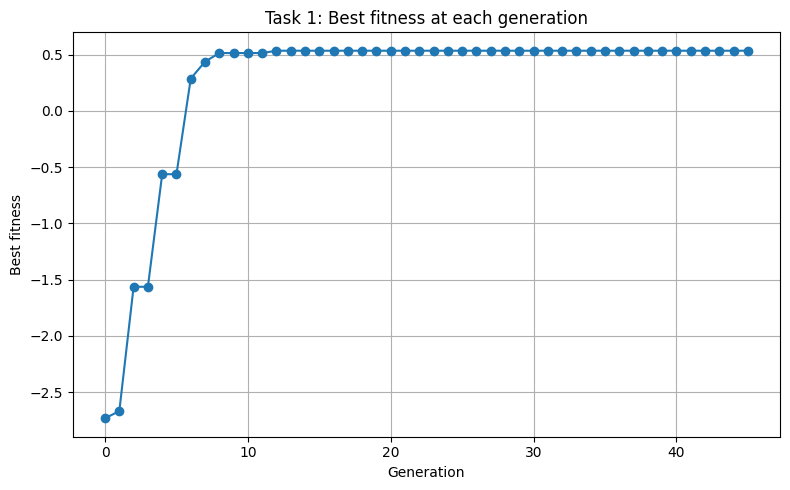

In [9]:
generations = logbook.select("gen")
best_fitness_per_generation = logbook.select("max")

plt.figure(figsize=(8, 5))
plt.plot(generations, best_fitness_per_generation, marker="o")
plt.xlabel("Generation")
plt.ylabel("Best fitness")
plt.title("Task 1: Best fitness at each generation")
plt.grid(True)
plt.tight_layout()
plt.savefig("task1_best_fitness.png", dpi=200)
plt.show()